#En este notebook aplicaremos las diferentes etapas de machine learning para un problema supervisado de clasificación realizando:

1.   Pre procesamiento.
2.   Entrenamiento del algoritmo
3.   Testeo del algoritmo.
4.   Cálculo de las métricas de rendimiento.
5.   Modelamiento



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn import preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
%matplotlib inline

In [7]:
df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Definición del problem

Contexto
Según la Organización Mundial de la Salud (OMS), el accidente cerebrovascular es la 2ª causa de muerte a nivel mundial, responsable de aproximadamente el 11% del total de muertes. Este conjunto de datos se utiliza para predecir si es probable que un paciente sume un accidente cerebrovascular en función de los parámetros de entrada como el sexo, la edad, varias enfermedades y el estado de tabaquismo. Cada fila de los datos proporciona información relavante sobre el paciente.

Información de atributos

1) id: identificador único\
2) género: "Masculino", "Femenino" u "Otro"\
3) edad: edad del paciente\
4) hipertensión: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión\
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca\
6) ever_married: "No" o "Sí"\
7) work_type: "hijos", "Govt_jov", "Never_worked", "privado" o "trabajador por cuenta propia"\
8) Residence_type: "Rural" o "Urbano"\
9) avg_glucose_level: nivel promedio de glucosa en sangre\
10) BMI: índice de masa corporal\
11) smoking_status: "anteriormente fumado", "nunca fumado", "fuma" o "Desconocido"*\
12) accidente cerebrovascular: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no











Información del DataSet preliminar.

In [10]:
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [16]:
df.shape

(5110, 12)

El DataSet contine 12 atributos y 5110 registros.

In [11]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3088,26267,Female,76.0,0,0,Yes,Self-employed,Urban,267.61,27.9,smokes,0
1497,5137,Male,64.0,0,0,Yes,Self-employed,Rural,210.00,30.7,formerly smoked,0
2842,20676,Male,29.0,0,0,No,Private,Rural,94.69,28.4,smokes,0
3001,4213,Male,33.0,0,0,No,Self-employed,Rural,91.53,38.8,formerly smoked,0
2800,8655,Female,51.0,0,1,Yes,Self-employed,Urban,100.96,33.4,never smoked,0


Revisar la contidad de valores nulos del DataFrame, el atributo bmi tiene valores nulos o missing values.


In [18]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Del análisis visual podemos observar las características de la variable objetivo stroke.\
Un 95.1% para los casos que hubo accidente cerebrovascular y un 4.9% para los que no hubo accidente cerebrovascular.\
Por lo tanto, tenemos desbalanceada la variable objetivo, por lo que podemos tener un modelo clasificador que acierte los casos que no hubo accidente cerebrovascular, pero que no sea acertivo en la predicción de casos que hubo accidente cerebrovascular.
Esto lleva a realizar un adecuado preprocesamiento de los datos y aplicar validación cruzada en la etapa de Machine Learning.


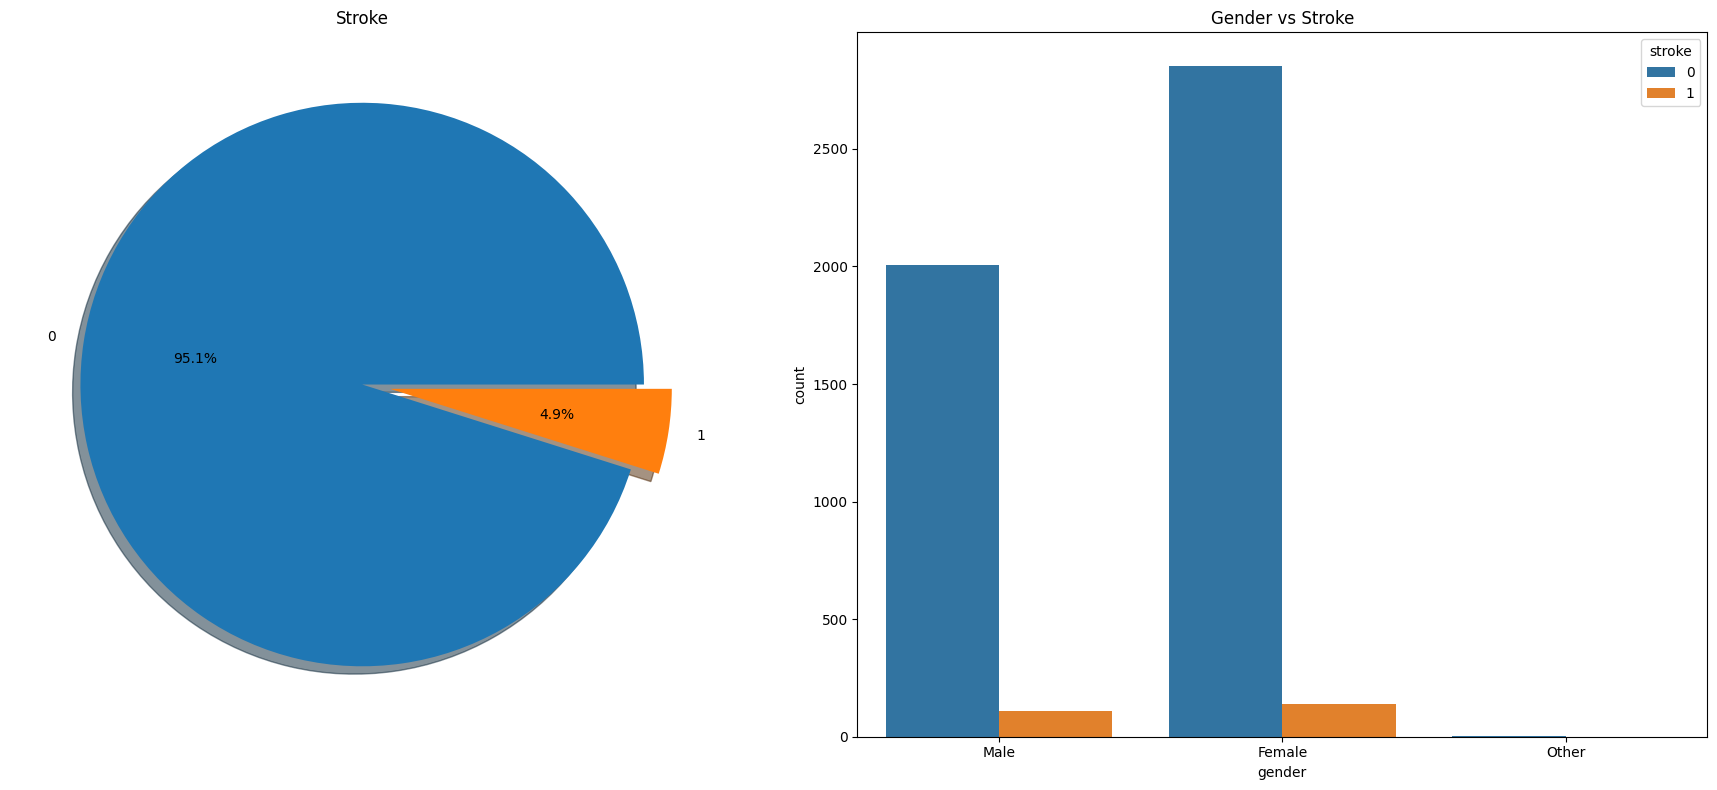

In [4]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

df['stroke'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=ax[0],
    explode=[0, 0.1],
    shadow=True
)
ax[0].set_title('Stroke')

sns.countplot(x='gender', hue='stroke', data=df, ax=ax[1])
ax[1].set_title('Gender vs Stroke')

plt.tight_layout()
plt.show()

Analisis de Características

In [20]:
df['gender'].count()

np.int64(5110)

In [21]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [ ]:
df.groupby(['gender', 'stroke'])['stroke'].count()

gender  stroke
Female  0         2853
        1          141
Male    0         2007
        1          108
Other   0            1
Name: stroke, dtype: int64

Gráfico con el promedio de mujeres y hombres que no tienen y tienen accidente cerebrovascular

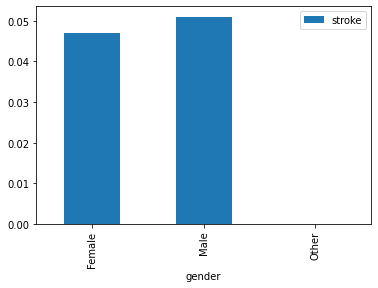

In [ ]:
df[ ['gender', 'stroke'] ].groupby(['gender']).mean().plot.bar()
plt.show()

In [ ]:
pd.crosstab(df['ever_married'], df['stroke'], margins=True ).style.background_gradient(cmap = 'summer_r')

stroke,0,1,All
ever_married,,,
No,1728,29,1757
Yes,3133,220,3353
All,4861,249,5110


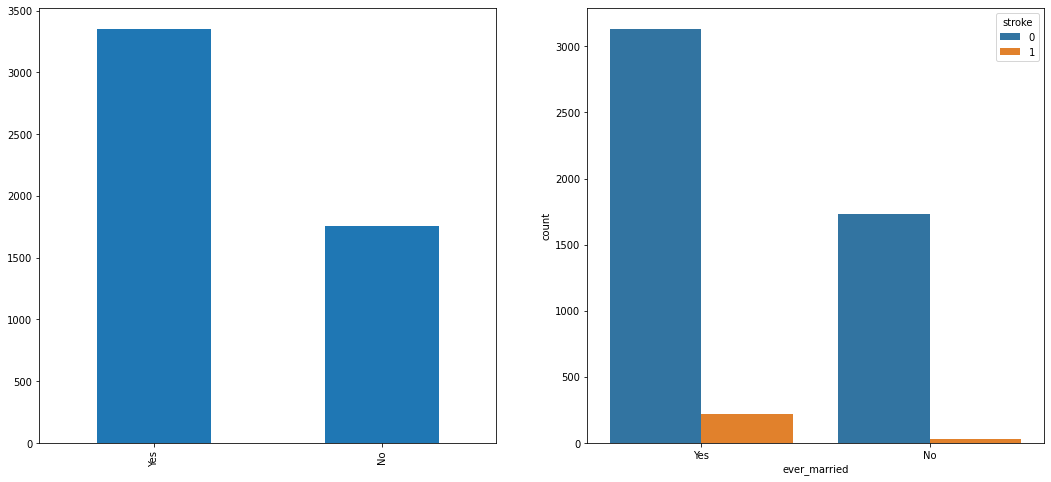

In [ ]:
f, ax = plt.subplots(1, 2, figsize = (18, 8))
df['ever_married'].value_counts().plot.bar(ax = ax[0])
sns.countplot('ever_married', hue='stroke', data = df, ax = ax[1])

In [ ]:
pd.crosstab([df['gender'], df['stroke']], df['ever_married'] , margins=True).style.background_gradient(cmap = 'summer_r')

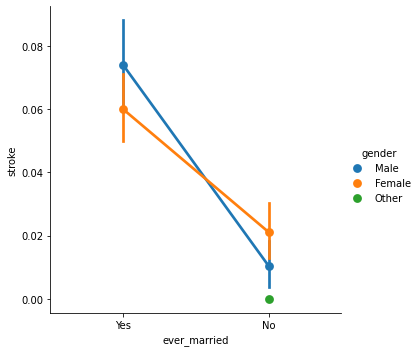

In [ ]:
sns.factorplot('ever_married', 'stroke', hue = 'gender', data = df)

I.- Preprocesamiento de los Datos. Limpieza de datos.


1.- Convertir valores string en valores numericos. Utilizando Label encoding y One hot encoding.\
2.- Corregir valores nulos con estrategia KNN imputer.\
3.- Convertir algunas variables continuas en rangos.\
4.- Eliminar caracteristicas innecesarias.








1.- Convertir valores string en valores numéricos:

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


a. Label encoder para variable categorica ordinal "ever_married".

In [ ]:
le = preprocessing.LabelEncoder()
data = df['ever_married']
le.fit(data)
data_transformada = le.transform(data)
df['ever_married'] = data_transformada
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,1,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,1,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,1,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,1,Private,Rural,166.29,25.6,formerly smoked,0


b. Label encoder para variable categorica ordinal "Residence_type".

In [ ]:
le = preprocessing.LabelEncoder()
data = df['Residence_type']
le.fit(data)
data_transformada = le.transform(data)
df['Residence_type'] = data_transformada
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,1,Private,1,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0


c. Label encoder para variable categorica ordinal "gender".

In [ ]:
le = preprocessing.LabelEncoder()
data = df['gender']
le.fit(data)
data_transformada = le.transform(data)
df['gender'] = data_transformada
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,Private,1,83.75,NaN,never smoked,0
5106,44873,0,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0
5107,19723,0,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0
5108,37544,1,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0


d. One hot encoder para variable categorica nominal "work_type".

In [ ]:
le = preprocessing.LabelEncoder()
data = df['work_type']
le.fit(data)
data_transformada = le.transform(data)
data_transformada.reshape(-1,1)
df['work_type'] = data_transformada
ohe=preprocessing.OneHotEncoder()
d = data_transformada.reshape(-1,1)
ohe.fit(d)
data_nueva = ohe.transform(d).toarray()
data_nueva = pd.DataFrame(data_nueva)
df=pd.concat([df, data_nueva], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,formerly smoked,1,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,NaN,never smoked,1,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,never smoked,1,0.0,0.0,1.0,0.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,smokes,1,0.0,0.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,never smoked,1,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,2,1,83.75,NaN,never smoked,0,0.0,0.0,1.0,0.0,0.0
5106,44873,0,81.0,0,0,1,3,1,125.20,40.0,never smoked,0,0.0,0.0,0.0,1.0,0.0
5107,19723,0,35.0,0,0,1,3,0,82.99,30.6,never smoked,0,0.0,0.0,0.0,1.0,0.0
5108,37544,1,51.0,0,0,1,2,0,166.29,25.6,formerly smoked,0,0.0,0.0,1.0,0.0,0.0


e. One hot encoder para variable categorica nominal "smoking_status".

In [ ]:
le1 = preprocessing.LabelEncoder()
data1 = df['smoking_status']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['smoking_status'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4,0,1,2,3
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,NaN,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,2,1,83.75,NaN,2,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5106,44873,0,81.0,0,0,1,3,1,125.20,40.0,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,19723,0,35.0,0,0,1,3,0,82.99,30.6,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,37544,1,51.0,0,0,1,2,0,166.29,25.6,1,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


2.- Corregir valores nulos con estrategia KNN imputer, variable "bmi"

a. Con tres vecinos.

In [ ]:
knn_imputer = KNNImputer(n_neighbors=3, weights="uniform")

In [ ]:
df[['bmi']] = knn_imputer.fit_transform(df[['bmi']])


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4,0,1,2,3
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0



b. Con cinco vecinos.



In [ ]:
knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")

In [ ]:
df[['bmi']] = knn_imputer.fit_transform(df[['bmi']])

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4,0,1,2,3
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Se seleciona cinco vecinos y se comprueba la existecia de missing value.

In [ ]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
0                    0
1                    0
2                    0
3                    0
4                    0
0                    0
1                    0
2                    0
3                    0
dtype: int64

3.- Convertir algunas variables continuas en rangos.

a. Convertir algunas variables continuas en rangos. "bmi".

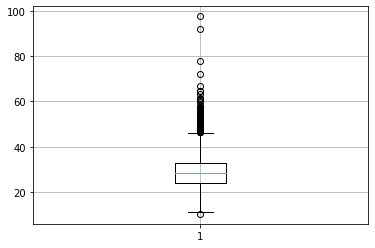

In [ ]:
plt.grid()
plt.boxplot(list(df['bmi']))
plt.show()

In [ ]:
print("El valor minimo de la variable indice masa corporal: ", df['bmi'].min())
print("El valor maximo de la variables indice masa corporal: ", df['bmi'].max())

El valor minimo de la variable indice masa corporal:  10.3
El valor maximo de la variables indice masa corporal:  97.6


In [ ]:
df['Indice_Masa_Corporal'] = pd.qcut(df['bmi'], 4)

In [ ]:
#Esta función corta cada uno de los tramos de indice de masa corporal  y en cuatro secciones
df.groupby(['Indice_Masa_Corporal'])['stroke'].mean().to_frame().style.background_gradient(cmap='summer_r')

,stroke
Indice_Masa_Corporal,
"(10.299000000000001, 23.8]",0.018547
"(23.8, 28.4]",0.052262
"(28.4, 32.8]",0.077891
"(32.8, 97.6]",0.046714


In [ ]:
#Creando rangos de Indice de Masa Corporal
df['Indice_Masa_Corporal'] = 0
df.loc[df['bmi'] <= 16, 'Indice_Masa_Corporal' ] = 0
df.loc[(df['bmi'] > 16) & (df['age'] <=32), 'Indice_Masa_Corporal' ] = 1
df.loc[(df['bmi'] > 32) & (df['age'] <=48), 'Indice_Masa_Corporal' ] = 2
df.loc[(df['bmi'] > 48) & (df['age'] <=64), 'Indice_Masa_Corporal' ] = 3
df.loc[ df['bmi'] > 64, 'Indice_Masa_Corporal' ] = 4

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4,0,1,2,3,Indice_Masa_Corporal
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


b. Convertir algunas variables continuas en rangos. "age".

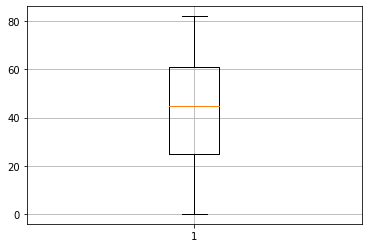

In [ ]:
plt.grid()
plt.boxplot((df['age']))
plt.show()

In [ ]:
# 1.- Creando rangos de edad
df['rango_de_edad'] = 0
df.loc[df['age'] <= 16, 'rango_de_edad' ] = 0
df.loc[(df['age'] > 16) & (df['age'] <=32), 'rango_de_edad' ] = 1
df.loc[(df['age'] > 32) & (df['age'] <=48), 'rango_de_edad' ] = 2
df.loc[(df['age'] > 48) & (df['age'] <=64), 'rango_de_edad' ] = 3
df.loc[ df['age'] > 64, 'rango_de_edad' ] = 4

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4,0,1,2,3,Indice_Masa_Corporal,rango_de_edad
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,4
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,3
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,4
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,3
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,4


In [ ]:
df['rango_de_edad'].value_counts()

3    1262
2    1101
4    1027
1     924
0     796
Name: rango_de_edad, dtype: int64

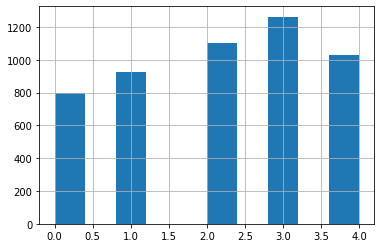

In [ ]:
df['rango_de_edad'].hist()

In [ ]:
df['rango_de_edad'].value_counts().to_frame().style.background_gradient(cmap='summer_r')

,rango_de_edad
3,1262
2,1101
4,1027
1,924
0,796


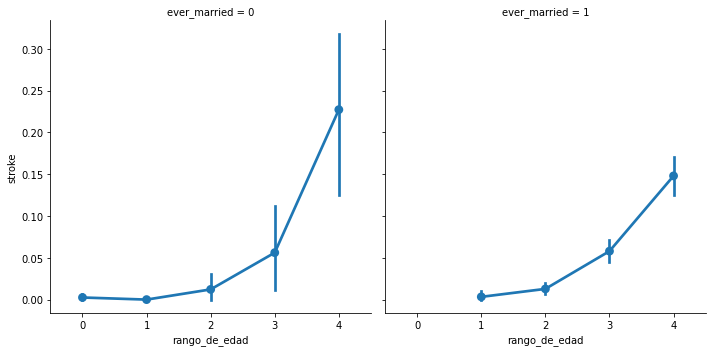

In [ ]:
sns.factorplot('rango_de_edad', 'stroke', data = df, col = 'ever_married')

c. Convertir algunas variables continuas en rangos. "avg_glucose_level".

Analizando el avg_glucose_level

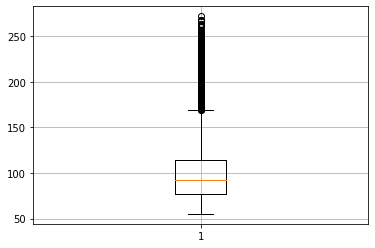

In [ ]:
plt.grid()
plt.boxplot(list(df['avg_glucose_level']))
plt.show()

In [ ]:
print("El valor minimo de la variables avg_glucose_level: ", df['avg_glucose_level'].min())
print("El valor maximo de la variables avg_glucose_level: ", df['avg_glucose_level'].max())

El valor minimo de la variables avg_glucose_level:  55.12
El valor maximo de la variables avg_glucose_level:  271.74


In [ ]:
df['Categoria_Nivel_Glucosa'] = pd.qcut(df['avg_glucose_level'], 4)

In [ ]:
#Esta función corta cada uno de los tramos del nivel de glucosa y en cuatro secciones
df.groupby(['Categoria_Nivel_Glucosa'])['stroke'].mean().to_frame().style.background_gradient(cmap='summer_r')

,stroke
Categoria_Nivel_Glucosa,
"(55.119, 77.245]",0.043036
"(77.245, 91.885]",0.029757
"(91.885, 114.09]",0.037559
"(114.09, 271.74]",0.084573


In [ ]:
# Creando categorias de Nivel_Glucosa
df['Categoria_Nivel_Glucosa'] = 0
df.loc[df['avg_glucose_level'] <= 77.245, 'Categoria_Nivel_Glucosa'] = 0
df.loc[ (df['avg_glucose_level'] > 77.245) & (df['avg_glucose_level'] <= 91.885), 'Categoria_Nivel_Glucosa'] = 1
df.loc[ (df['avg_glucose_level'] > 91.885) & (df['avg_glucose_level'] <= 114.09), 'Categoria_Nivel_Glucosa'] = 2
df.loc[ (df['avg_glucose_level'] > 114.09) & (df['avg_glucose_level'] <= 271.74), 'Categoria_Nivel_Glucosa'] = 3


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1,2,3,4,0,1,2,3,Indice_Masa_Corporal,rango_de_edad,Categoria_Nivel_Glucosa
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,4,3
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,3,3
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,4,2
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,3,3
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,4,3


4.- Eliminar caracteristicas innecesarias.

In [ ]:
df.drop(['id', 'avg_glucose_level', 'bmi', 'age'], axis =1, inplace = True)

In [ ]:
df.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,0,1,2,3,4,0,1,2,3,Indice_Masa_Corporal,rango_de_edad,Categoria_Nivel_Glucosa
0,1,0,1,1,2,1,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,4,3
1,0,0,0,1,3,0,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,3,3
2,1,0,1,1,2,0,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,4,2
3,0,0,0,1,2,1,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,3,3
4,0,1,0,1,3,0,2,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,4,3


II.Aplicación algoritmo(s) de aprendizaje supervisado.

In [ ]:
Y = df['stroke']

In [ ]:
X = df.drop(columns=['stroke'])

In [ ]:
X = StandardScaler().fit_transform(X)

In [ ]:
df_X_Scaler = pd.DataFrame(X)

In [ ]:
df_X_Scaler.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03
mean,-4.859996e-16,-2.076899e-15,-5.816797e-15,-1.190394e-15,1.167581e-16,-4.984054e-17,2.602832e-17,8.496791e-16,5.322335e-16,-1.861351e-15,-3.194227e-16,2.907980e-15,7.539088e-16,-1.188840e-15,2.055759e-16,1.371593e-16,1.296462e-15,5.038878e-15,-2.054130e-16
std,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00
min,-8.403440e-01,-3.286019e-01,-2.389468e-01,-1.381436e+00,-1.988384e+00,-1.016178e+00,-1.285114e+00,-3.841106e-01,-6.575636e-02,-1.157010e+00,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01,-7.304445e-01,-1.594048e+00,-1.341466e+00
25%,-8.403440e-01,-3.286019e-01,-2.389468e-01,-1.381436e+00,-1.538364e-01,-1.016178e+00,-1.285114e+00,-3.841106e-01,-6.575636e-02,-1.157010e+00,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01,-7.304445e-01,-8.548841e-01,-1.117859e+00
50%,-8.403440e-01,-3.286019e-01,-2.389468e-01,7.238842e-01,-1.538364e-01,9.840797e-01,5.815523e-01,-3.841106e-01,-6.575636e-02,8.642966e-01,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01,-7.304445e-01,-1.157204e-01,1.750347e-04
75%,1.188073e+00,-3.286019e-01,-2.389468e-01,7.238842e-01,7.634376e-01,9.840797e-01,5.815523e-01,-3.841106e-01,-6.575636e-02,8.642966e-01,-4.368805e-01,-3.941122e-01,1.519732e+00,-4.576761e-01,1.304165e+00,-4.273133e-01,5.539916e-01,6.234434e-01,4.473886e-01
max,3.216489e+00,3.043196e+00,4.185032e+00,7.238842e-01,1.680712e+00,9.840797e-01,1.514885e+00,2.603417e+00,1.520765e+01,8.642966e-01,2.288955e+00,2.537348e+00,1.519732e+00,2.184951e+00,1.304165e+00,2.340204e+00,4.407300e+00,1.362607e+00,1.341816e+00


In [ ]:
from sklearn.model_selection import train_test_split
seed = 0
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = seed)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#Creamos el clasificador y lo entrenamos
knn = KNeighborsClassifier(n_neighbors=4, weights='uniform')
knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=4, p=2,
                     weights='uniform')

In [ ]:
#Prediccion del testing Set
y_predicted = knn.predict(X_test)

In [ ]:
from sklearn import metrics
cf = metrics.confusion_matrix(y_test, y_predicted)
cf

array([[967,   1],
       [ 54,   0]])

In [ ]:
print(metrics.classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [ ]:
y_predicted = svm.predict(X_test)

In [ ]:
from sklearn import metrics
cf = metrics.confusion_matrix(y_test, y_predicted)
cf

array([[968,   0],
       [ 54,   0]])

In [ ]:
print(metrics.classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
seed = 0
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = seed, stratify = Y)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=4, weights='uniform')
knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=4, p=2,
                     weights='uniform')

In [ ]:
y_predicted = knn.predict(X_test)

In [ ]:
from sklearn import metrics
cf = metrics.confusion_matrix(y_test, y_predicted)
cf

array([[969,   3],
       [ 50,   0]])

In [ ]:
print(metrics.classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)


SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [ ]:
y_predicted = svm.predict(X_test)

In [ ]:
from sklearn import metrics
cf = metrics.confusion_matrix(y_test, y_predicted)
cf

array([[972,   0],
       [ 50,   0]])

In [ ]:
print(metrics.classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.model_selection import train_test_split
seed = 0
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = seed)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV

weights_range = ['uniform', 'distance']
k_range = range(1,21)
param_grid = dict(weights = weights_range, n_neighbors = k_range)

cv = StratifiedShuffleSplit(n_splits = 5, test_size = 0.2, random_state = 113)
knn = GridSearchCV(KNeighborsClassifier(), param_grid = param_grid, cv = cv, scoring = 'accuracy', refit = True )
knn.fit(X_train, y_train)
print("The best parameters are %s with a score of %0.2f" % (knn.best_params_, knn.best_score_))

The best parameters are {'n_neighbors': 6, 'weights': 'uniform'} with a score of 0.95


In [ ]:
from sklearn import metrics
predicted = knn.predict(X_test)
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



In [ ]:
cf = metrics.confusion_matrix(y_test, predicted)
cf

array([[968,   0],
       [ 54,   0]])

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param1 = [2, 5, 10, 15, 20, 25, 30, 50]
param2 = ['gini','entropy']
param_grid = dict(n_estimators = param1, criterion = param2)

cv = StratifiedShuffleSplit(n_splits = 5, test_size = 0.2, random_state = 113)
RF = GridSearchCV(RandomForestClassifier(), param_grid = param_grid, cv = cv, scoring = 'accuracy', refit = True )
RF.fit(X_train, y_train)
print("The best parameters are %s with a score of %0.2f" % (RF.best_params_, RF.best_score_))

The best parameters are {'criterion': 'entropy', 'n_estimators': 15} with a score of 0.94


In [ ]:
cf = metrics.confusion_matrix(y_test, predicted)
cf

array([[968,   0],
       [ 54,   0]])

In [ ]:
from sklearn import metrics
predicted = RF.predict(X_test)
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       968
           1       0.08      0.02      0.03        54

    accuracy                           0.94      1022
   macro avg       0.52      0.50      0.50      1022
weighted avg       0.90      0.94      0.92      1022



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.model_selection import train_test_split
seed = 0
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = seed)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV

weights_range = ['uniform', 'distance']
k_range = range(1,21)
param_grid = dict(weights = weights_range, n_neighbors = k_range)

cv = StratifiedShuffleSplit(n_splits = 5, test_size = 0.2, random_state = 113)
knn = GridSearchCV(KNeighborsClassifier(), param_grid = param_grid, cv = cv, scoring = 'accuracy', refit = True )
knn.fit(X_train, y_train)
print("The best parameters are %s with a score of %0.2f" % (knn.best_params_, knn.best_score_))

The best parameters are {'n_neighbors': 6, 'weights': 'uniform'} with a score of 0.95


In [ ]:
from sklearn import metrics
predicted = knn.predict(X_test)
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



In [ ]:
cf = metrics.confusion_matrix(y_test, predicted)
cf

array([[968,   0],
       [ 54,   0]])

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param1 = [2, 5, 10, 15, 20, 25, 30, 50]
param2 = ['gini','entropy']
param_grid = dict(n_estimators = param1, criterion = param2)

cv = StratifiedShuffleSplit(n_splits = 5, test_size = 0.2, random_state = 113)
RF = GridSearchCV(RandomForestClassifier(), param_grid = param_grid, cv = cv, scoring = 'accuracy', refit = True )
RF.fit(X_train, y_train)
print("The best parameters are %s with a score of %0.2f" % (RF.best_params_, RF.best_score_))

The best parameters are {'criterion': 'entropy', 'n_estimators': 50} with a score of 0.94


In [ ]:
cf = metrics.confusion_matrix(y_test, predicted)
cf

array([[968,   0],
       [ 54,   0]])

In [ ]:
from sklearn import metrics
predicted = RF.predict(X_test)
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.93      1022
   macro avg       0.47      0.49      0.48      1022
weighted avg       0.90      0.93      0.91      1022



Resumen de algoritmos de Clasificación

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
modelos = []
modelos.append(("LogisticRegression", LogisticRegression()))
modelos.append(("DecisionTreeClassifier", DecisionTreeClassifier()))
modelos.append(("svm", SVC()))
modelos.append(("KNeighborsClassifier", KNeighborsClassifier()))

puntuacion = []
for nombre, modelo in modelos:
  modelo.fit(X_train, y_train)
  resultado = modelo.score(X_test, y_test)
  puntuacion.append((nombre,modelo.predict(X_test)))
  print("El redimiento de modelo {model} es {ren:.3f}%".format(
       model = nombre, ren = resultado*100
  ))

El redimiento de modelo LogisticRegression es 94.716%
El redimiento de modelo DecisionTreeClassifier es 92.172%
El redimiento de modelo svm es 94.716%
El redimiento de modelo KNeighborsClassifier es 94.423%


Aplicando algoritmos ensamblados para mejorar los resultados. Bagging.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)
mo = DecisionTreeClassifier()
model = BaggingClassifier(mo, n_estimators=10)

params = {"base_estimator__max_depth": [2,3],
          "max_samples": [0.1,0.2],
          "base_estimator__min_samples_split": [2,3,4]}
grid = GridSearchCV(estimator=model, param_grid=params,cv=5)
_=grid.fit(X_train, y_train)

In [ ]:
print(grid.best_score_)
print(grid.best_params_)
#pd.DataFrame(grid.cv_results_)

0.9520548970082567
{'base_estimator__max_depth': 2, 'base_estimator__min_samples_split': 2, 'max_samples': 0.1}


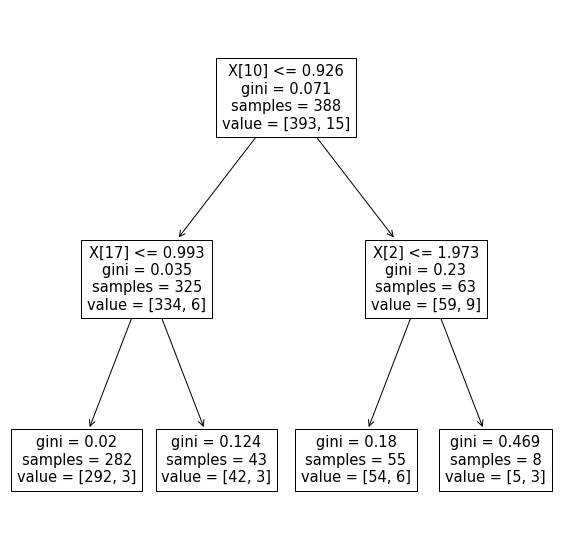

In [ ]:
# Visualizamos 1 sólo árbol dentro del "bosque" generado por Bagging
import matplotlib.pyplot as plt
from sklearn import tree

mo_ = grid.best_estimator_.estimators_[0]
plt.subplots(1,1,figsize=(10,10))
_= tree.plot_tree(mo_)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_hat = grid.predict(X_test)
print(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat))

[[969   0]
 [ 53   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       969
           1       0.00      0.00      0.00        53

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



In [ ]:
grid = GridSearchCV(estimator=model, param_grid=params,cv=10, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=10, error_score=nan,
             estimator=BaggingClassifier(base_estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                                                               class_weight=None,
                                                                               criterion='gini',
                                                                               max_depth=None,
                                                                               max_features=None,
                                                                               max_leaf_nodes=None,
                                                                               min_impurity_decrease=0.0,
                                                                               min_impurity_split=None,
                                                                               min_samples_leaf=1,
                                                                        

In [ ]:
print(grid.best_score_)
print(grid.best_params_)

0.9520554676638382
{'base_estimator__max_depth': 2, 'base_estimator__min_samples_split': 2, 'max_samples': 0.1}


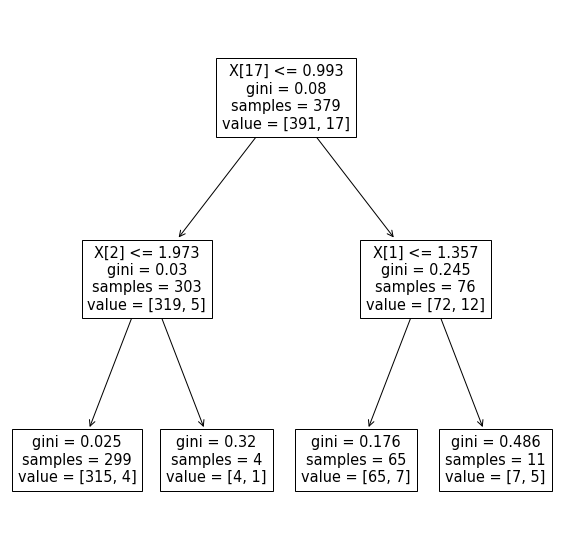

In [ ]:
# Árbol ganador
import matplotlib.pyplot as plt
from sklearn import tree

mo_ = grid.best_estimator_.estimators_[0]
plt.subplots(1,1,figsize=(10,10))
_= tree.plot_tree(mo_)

AdaBoost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

mo = DecisionTreeClassifier()
model = AdaBoostClassifier(mo)

params = {"n_estimators": [10],
          "base_estimator__max_depth": [2,3],
          "base_estimator__min_samples_split": [2,3,4],
          "base_estimator__max_leaf_nodes": [5,8]}

grid = GridSearchCV(estimator=model, param_grid=params,cv=5)
_=grid.fit(X_train, y_train)

In [ ]:
print(grid.best_score_)
print(grid.best_params_)

0.9493642133992513
{'base_estimator__max_depth': 3, 'base_estimator__max_leaf_nodes': 5, 'base_estimator__min_samples_split': 3, 'n_estimators': 10}


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_hat = grid.predict(X_test)
print(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat))

[[979   0]
 [ 42   1]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       979
           1       1.00      0.02      0.05        43

    accuracy                           0.96      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.96      0.96      0.94      1022



Gradient Boosting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

model = GradientBoostingClassifier()

params = {"n_estimators": [10],
          "max_depth": [2,3],
          "min_samples_split": [2,3,4],
          "max_leaf_nodes": [5,8]}

grid = GridSearchCV(estimator=model, param_grid=params,cv=5)
_=grid.fit(X_train, y_train)

In [ ]:
print(grid.best_score_)
print(grid.best_params_)

0.9527889918689942
{'max_depth': 2, 'max_leaf_nodes': 5, 'min_samples_split': 2, 'n_estimators': 10}


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_hat = grid.predict(X_test)
print(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat))

[[966   0]
 [ 56   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       966
           1       0.00      0.00      0.00        56

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.89      0.95      0.92      1022



Conclusión

Luego de concluido el proceso de Machine Learning, llego a la conclusión que el algoritmo AdaBoost se obtienen mejores resultados, ya que logra clasificar de forma asertiva tanto casos en que ocurre un accidente cerebro vascular como en casos en que no ocurre un accidente cerebro vascular.